<a href="https://colab.research.google.com/github/julia-zhmurko/JuliaZhmurko-ML/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D1%96_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B8/%D0%96%D0%BC%D1%83%D1%80%D0%BA%D0%BE_%D0%AE%D0%BB%D1%96%D1%8F_%D0%A4%D0%86%D0%A2_4_10_%22%D0%9B%D0%912_%D0%9C%D0%9D_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [133]:
import numpy as np
import pandas as pd
import requests
import io

# Лабораторна робота 2.
**Автор:** студентка групи ФІТ 4-10
Жмурко Юлія Андріївна

**Була присутня на парі**

# Завдання 1



Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

**1.** Вивести перші 5 рядків датасета

In [134]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers ={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(io.StringIO(html))
df = tables[2]
print("Виведення перших 5 рядків датасета df:")
df.head()

Виведення перших 5 рядків датасета df:


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [135]:
print("Назви стовпців у датасеті (df.columns)")
df.columns

Назви стовпців у датасеті (df.columns)


Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

**2.**	Визначити розмір датасета.

In [136]:
rows, cols = df.shape
print("Розмірність завантаженого датасета df:")
print(f"Загальна кількість рядків: {rows}")
print(f"Загальна кількість колонок: {cols}")
print(f"Загальна кількість елементів (df.size): {df.size}")

print("\nДетальна інформація про датасет (df.info):")
df.info()

Розмірність завантаженого датасета df:
Загальна кількість рядків: 222
Загальна кількість колонок: 4
Загальна кількість елементів (df.size): 888

Детальна інформація про датасет (df.info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


**3.**	Змінити назви стовпчиків на власний розсуд.

In [137]:
df.columns = (df.columns.str.replace(r'(?:\s*\[\d+\])+', '', regex = True))

new_columns = {
    'Country/Territory': 'Country',
    'IMF (2026)': 'GDP_IMF_2026',
    'World Bank (2025)': 'GDP_WorldBank_2025',
    'United Nations (2024)': 'GDP_UN_2024'
}

df = df.rename(columns = new_columns)

print("Оновлені назви стовпчиків:")
print(df.columns)

df

Оновлені назви стовпчиків:
Index(['Country', 'GDP_IMF_2026', 'GDP_WorldBank_2025', 'GDP_UN_2024'], dtype='object')


,Country,GDP_IMF_2026,GDP_WorldBank_2025,GDP_UN_2024
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


**4.**	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [138]:
print("Кількість пропущених значень (до зміни типів):")
df.isnull().sum()

Кількість пропущених значень (до зміни типів):


,0
Country,0
GDP_IMF_2026,0
GDP_WorldBank_2025,0
GDP_UN_2024,0


In [139]:
gdp_cols = ['GDP_IMF_2026', 'GDP_WorldBank_2025', 'GDP_UN_2024']
df[gdp_cols] = df[gdp_cols].apply(pd.to_numeric, errors = 'coerce')

print("Типи даних після перетворення:")
print(df.dtypes)
df

Типи даних після перетворення:
Country                object
GDP_IMF_2026          float64
GDP_WorldBank_2025    float64
GDP_UN_2024           float64
dtype: object


,Country,GDP_IMF_2026,GDP_WorldBank_2025,GDP_UN_2024
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [140]:
print("Кількість пропущених значень після конвертації в числа:")
df.isnull().sum()

Кількість пропущених значень після конвертації в числа:


,0
Country,0
GDP_IMF_2026,30
GDP_WorldBank_2025,35
GDP_UN_2024,9


In [141]:
# Заміна NaN середнім значенням по кожному рядку (ігноруючи першу колонку з країнами)
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda row: row.fillna(row.mean()), axis = 1)

print("Перевірка пропусків після заповнення середнім по рядках:")
df.isnull().sum()

Перевірка пропусків після заповнення середнім по рядках:


,0
Country,0
GDP_IMF_2026,8
GDP_WorldBank_2025,8
GDP_UN_2024,8


In [142]:
# Дозаповнення пропусків, що залишилися, середнім значенням по відповідних стовпчиках
col_means = df.iloc[:, 1:].mean()
df.iloc[:, 1:] = df.iloc[:, 1:].fillna(col_means)

print("Остаточна перевірка: пропущені значення повністю відсутні")
df.isnull().sum()

Остаточна перевірка: пропущені значення повністю відсутні


,0
Country,0
GDP_IMF_2026,0
GDP_WorldBank_2025,0
GDP_UN_2024,0


**5.** Ще раз вивести датасет

In [143]:
print("Оновлений датасет df після обробки пропусків:")
df

Оновлений датасет df після обробки пропусків:


,Country,GDP_IMF_2026,GDP_WorldBank_2025,GDP_UN_2024
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0


**6.**	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [144]:
duplicates_count = df.duplicated().sum()
print(f"Кількість знайдених дублікатів: {duplicates_count}")

Кількість знайдених дублікатів: 0


In [145]:
#1
#df.drop_duplicates(inplace = True)

#2
if duplicates_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Дублікати успішно видалені")
else:
    print("Дублікатів у датасеті df не виявлено")

Дублікатів у датасеті df не виявлено


In [146]:
df = df[df['Country'] != 'World'].reset_index(drop = True)

df['Country'] = df['Country'].str.replace(r'\[.*\]', '', regex = True).str.strip()

print(f"Поточний розмір датасета після перевірки: {df.shape}")
df

Поточний розмір датасета після перевірки: (221, 4)


,Country,GDP_IMF_2026,GDP_WorldBank_2025,GDP_UN_2024
0,United States,32383920.0,30769700.0,29298000.0
1,China,20851593.0,19498039.0,18743802.0
2,Germany,5452858.0,5050923.0,4659929.0
3,Japan,4379253.0,4435163.0,4026211.0
4,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
216,Palau,377.0,345.0,310.0
217,Marshall Islands,342.0,308.0,281.0
218,Nauru,196.0,176.0,187.0
219,Montserrat,81.0,81.0,81.0


**7.**	Вивести описову статистику датасету describe()

In [147]:
print("Описова статистика датасета ВВП:")
df.describe()

Описова статистика датасета ВВП:


,GDP_IMF_2026,GDP_WorldBank_2025,GDP_UN_2024
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.158774e+05,5.760663e+05,5.434068e+05
std,2.675916e+06,2.530050e+06,2.412230e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


**8.** Визначте відхилення (різницю) між показниками GDP_IMF_2026 та GDP_WorldBank_2025 для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [148]:
df['GDP_Diff'] = (df['GDP_IMF_2026'] - df['GDP_WorldBank_2025']).abs()

max_diff_row = df.loc[df['GDP_Diff'].idxmax()]
top_country = max_diff_row['Country']
max_diff_val = max_diff_row['GDP_Diff']

print(f"Країна з найбільшою різницею між GDP_IMF_2026 та GDP_WorldBank_2025: {top_country} (різниця складає {max_diff_val})")

df.sort_values(by = 'GDP_Diff', ascending = False).head(10)

Країна з найбільшою різницею між GDP_IMF_2026 та GDP_WorldBank_2025: United States (різниця складає 1614220.0)


,Country,GDP_IMF_2026,GDP_WorldBank_2025,GDP_UN_2024,GDP_Diff
0,United States,32383920.0,30769700.0,29298000.0,1614220.0
1,China,20851593.0,19498039.0,18743802.0,1353554.0
2,Germany,5452858.0,5050923.0,4659929.0,401935.0
9,Brazil,2635912.0,2279920.0,2185822.0,355992.0
11,Australia,2123963.0,1798519.0,1830610.0,325444.0
12,Mexico,2120855.0,1832641.0,1852723.0,288214.0
4,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,France,3596094.0,3366316.0,3160443.0,229778.0
5,India,4153191.0,3956067.0,3952244.0,197124.0
10,Canada,2507340.0,2319900.0,2270076.0,187440.0


**Найбільша абсолютна різниця між оцінками МВФ та Світового Банку спостерігається у United States (відхилення складає 1 614 220 млн USD).**

**Найбільші розходження в абсолютних числах припадають саме на країни з найбільшими економіками світу — США, Китай (1 353 554 млн USD), Німеччину (401 935 млн USD), Бразилію (355 992 млн USD) та Австралію (325 444 млн USD).**

**9.**	Обчисліть кореляцію між показниками GDP_IMF_2026, GDP_WorldBank_2025 та GDP_UN_2024. Які пари змінних мають найвищу кореляцію?

In [149]:
corr_imf_wb = df['GDP_IMF_2026'].corr(df['GDP_WorldBank_2025'])
corr_imf_un = df['GDP_IMF_2026'].corr(df['GDP_UN_2024'])
corr_wb_un = df['GDP_WorldBank_2025'].corr(df['GDP_UN_2024'])

print("Кореляція між показниками ВВП:")
print(f"GDP_IMF_2026 та GDP_WorldBank_2025: {corr_imf_wb}")
print(f"GDP_IMF_2026 та GDP_UN_2024: {corr_imf_un}")
print(f"GDP_WorldBank_2025 та GDP_UN_2024: {corr_wb_un}")

Кореляція між показниками ВВП:
GDP_IMF_2026 та GDP_WorldBank_2025: 0.9998779628509464
GDP_IMF_2026 та GDP_UN_2024: 0.999816606157696
GDP_WorldBank_2025 та GDP_UN_2024: 0.9998604773125492


In [150]:
correlations = {
    "GDP_IMF_2026 та GDP_WorldBank_2025": corr_imf_wb,
    "GDP_IMF_2026 та GDP_UN_2024": corr_imf_un,
    "GDP_WorldBank_2025 та GDP_UN_2024": corr_wb_un
}

max_pair = max(correlations, key = correlations.get)
max_value = correlations[max_pair]

print(f"Найвищу кореляцію мають показники: {max_pair} (коефіцієнт: {max_value})")

Найвищу кореляцію мають показники: GDP_IMF_2026 та GDP_WorldBank_2025 (коефіцієнт: 0.9998779628509464)


**10.** Обчислити середнє значення за стовпцями

In [151]:
mean_imf = df['GDP_IMF_2026'].mean()
print(f"Середнє значення GDP_IMF_2026: {mean_imf}")

Середнє значення GDP_IMF_2026: 615877.374740982


In [152]:
mean_wb = df['GDP_WorldBank_2025'].mean()
print(f"Середнє значення GDP_WorldBank_2025: {mean_wb}")

Середнє значення GDP_WorldBank_2025: 576066.3084535036


In [153]:
mean_un = df['GDP_UN_2024'].mean()
print(f"Середнє значення GDP_UN_2024: {mean_un}")

Середнє значення GDP_UN_2024: 543406.7526959023


**11.**	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [154]:
df['GDP_Std'] = df[['GDP_IMF_2026', 'GDP_WorldBank_2025', 'GDP_UN_2024']].std(axis=1)

max_std_row = df.loc[df['GDP_Std'].idxmax()]
top_std_country = max_std_row['Country']
max_std_val = max_std_row['GDP_Std']

print(f"Країна з найвищою варіативністю у показниках: {top_std_country}")
print(f"Стандартне відхилення складає: {max_std_val}")

df.sort_values(by = 'GDP_Std', ascending = False).head(10)

Країна з найвищою варіативністю у показниках: United States
Стандартне відхилення складає: 1543508.4140144275


,Country,GDP_IMF_2026,GDP_WorldBank_2025,GDP_UN_2024,GDP_Diff,GDP_Std
0,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.543508e+06
1,China,20851593.0,19498039.0,18743802.0,1353554.0,1.068002e+06
2,Germany,5452858.0,5050923.0,4659929.0,401935.0,3.964771e+05
4,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,2.898838e+05
8,Russia,2656452.0,2561310.0,2173386.0,95142.0,2.558938e+05
9,Brazil,2635912.0,2279920.0,2185822.0,355992.0,2.374046e+05
3,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.217380e+05
6,France,3596094.0,3366316.0,3160443.0,229778.0,2.179348e+05
13,Spain,2091222.0,1906453.0,1722746.0,184769.0,1.842383e+05
11,Australia,2123963.0,1798519.0,1830610.0,325444.0,1.793505e+05


**12.**	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (GDP_IMF_2026, GDP_WorldBank_2025, GDP_UN_2024).

In [155]:
max_imf = df.loc[df['GDP_IMF_2026'].idxmax()]
min_imf = df.loc[df['GDP_IMF_2026'].idxmin()]

max_wb = df.loc[df['GDP_WorldBank_2025'].idxmax()]
min_wb = df.loc[df['GDP_WorldBank_2025'].idxmin()]

max_un = df.loc[df['GDP_UN_2024'].idxmax()]
min_un = df.loc[df['GDP_UN_2024'].idxmin()]

print("GDP_IMF_2026:")
print(f"Найвищий:  {max_imf['Country']} ({max_imf['GDP_IMF_2026']})")
print(f"Найнижчий: {min_imf['Country']} ({min_imf['GDP_IMF_2026']})\n")

print("GDP_WorldBank_2025:")
print(f"Найвищий:  {max_wb['Country']} ({max_wb['GDP_WorldBank_2025']})")
print(f"Найнижчий: {min_wb['Country']} ({min_wb['GDP_WorldBank_2025']})\n")

print("GDP_UN_2024:")
print(f"Найвищий:  {max_un['Country']} ({max_un['GDP_UN_2024']})")
print(f"Найнижчий: {min_un['Country']} ({min_un['GDP_UN_2024']})")

GDP_IMF_2026:
Найвищий:  United States (32383920.0)
Найнижчий: Tuvalu (65.0)

GDP_WorldBank_2025:
Найвищий:  United States (30769700.0)
Найнижчий: Tuvalu (57.0)

GDP_UN_2024:
Найвищий:  United States (29298000.0)
Найнижчий: Tuvalu (56.0)


**13.**	Побудуйте гістограму для розподілу показників GDP_IMF_2026 серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

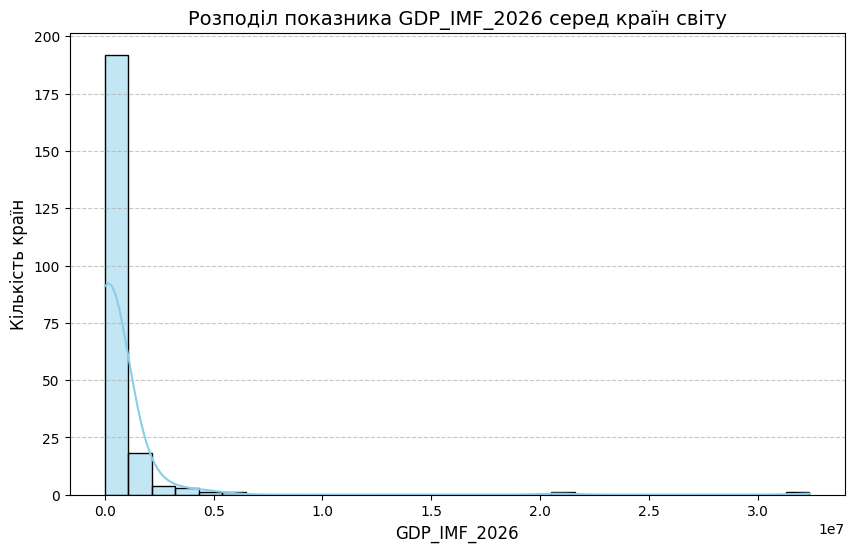

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 6))

sns.histplot(df['GDP_IMF_2026'], bins = 30, kde = True, color = 'skyblue', edgecolor = 'black')

plt.title('Розподіл показника GDP_IMF_2026 серед країн світу', fontsize = 14)
plt.xlabel('GDP_IMF_2026', fontsize = 12)
plt.ylabel('Кількість країн', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.show()

**Розподіл має асиметричний вигляд із сильною правобічною асиметрією. Переважна більшість країн зосереджена у першому стовпчику біля нуля (низький та середній ВВП).**

**На графіку виразно видно окремі поодинокі стовпчики далеко праворуч у зоні $2.0 \cdot 10^7$ та $3.0 \cdot 10^7$ — це екстремальні викиди, якими є економіки США та Китаю.**

**14.**	Розрахуйте частку кожної країни в загальному значенні для кожного року (GDP_IMF_2026, GDP_WorldBank_2025, GDP_UN_2024).
 Як змінюються частки країн з часом (дати відповідь)?

In [157]:
df['Share_IMF_%'] = (df['GDP_IMF_2026'] / df['GDP_IMF_2026'].sum()) * 100
df['Share_WorldBank_%'] = (df['GDP_WorldBank_2025'] / df['GDP_WorldBank_2025'].sum()) * 100
df['Share_UN_%'] = (df['GDP_UN_2024'] / df['GDP_UN_2024'].sum()) * 100

df.head(10)

,Country,GDP_IMF_2026,GDP_WorldBank_2025,GDP_UN_2024,GDP_Diff,GDP_Std,Share_IMF_%,Share_WorldBank_%,Share_UN_%
0,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.543508e+06,23.792654,24.168991,24.396115
1,China,20851593.0,19498039.0,18743802.0,1353554.0,1.068002e+06,15.319787,15.315324,15.607753
2,Germany,5452858.0,5050923.0,4659929.0,401935.0,3.964771e+05,4.006246,3.967400,3.880270
3,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.217380e+05,3.217463,3.483733,3.352581
4,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,2.898838e+05,3.133369,3.143954,3.069192
5,India,4153191.0,3956067.0,3952244.0,197124.0,1.149291e+05,3.051374,3.107412,3.290989
6,France,3596094.0,3366316.0,3160443.0,229778.0,2.179348e+05,2.642071,2.644175,2.631665
7,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.787283e+05,2.011745,2.004198,1.982486
8,Russia,2656452.0,2561310.0,2173386.0,95142.0,2.558938e+05,1.951711,2.011858,1.809754
9,Brazil,2635912.0,2279920.0,2185822.0,355992.0,2.374046e+05,1.936620,1.790832,1.820109


**Частки найбільших економік (зокрема США та Китаю) залишаються колосальними та формують значну частину світового ВВП в усіх трьох джерелах (США утримують близько 24-25% світового ВВП, Китай — близько 16–17%).**

**Відносні частки більшості розвинених країн (Німеччина, Японія, Великобританія) демонструють незначні коливання між роками, що свідчить про загальну стабільність глобальної структури розподілу багатства.**

**15.**	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

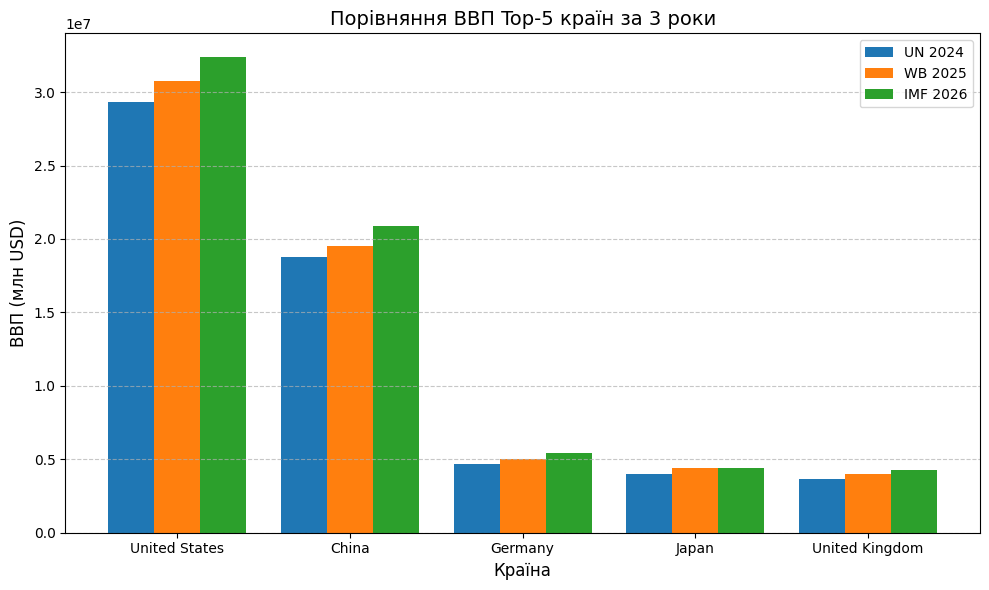

In [158]:
import matplotlib.pyplot as plt

top5_df = df.head(5).set_index('Country')[['GDP_UN_2024', 'GDP_WorldBank_2025', 'GDP_IMF_2026']]

top5_df.plot(kind = 'bar', figsize = (10, 6), width = 0.8)

plt.title('Порівняння ВВП Top-5 країн за 3 роки', fontsize = 14)
plt.ylabel('ВВП (млн USD)', fontsize = 12)
plt.xlabel('Країна', fontsize = 12)
plt.xticks(rotation = 0)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.legend(['UN 2024', 'WB 2025', 'IMF 2026'])

plt.tight_layout()
plt.show()

**Більшість провідних економік (США, Китай, Німеччина, Велика Британія) показують впевнений позитивний тренд зростання ВВП протягом 2024–2026 років.**

**Країни на кшталт Японії показують стагнацію (відсутність зростання між 2025 та 2026 роками), що пояснюється впливом валютно-курсової переоцінки при перерахунку в долари США.**